# SVRによる材料寿命 PredictedHours の予測

`Material_Lifespan_Dataset.csv` を使い、SVR（Support Vector Regression）で材料寿命 `PredictedHours` を予測します。

このフォルダに `Material_Lifespan_Dataset.csv` がない場合は、同じ内容を機械学習用にエンコードした `Material_Lifespan_Dataset_encoded_sklearn.csv` を読み込みます。


【Python セミナー 第4回】  
材料寿命データを学習用データとテスト用データに分け、説明変数を標準化してからSVRで回帰モデルを作成する。


In [1]:
# 必要なライブラリを読み込む。
# pathlib の Path は、CSVファイルが存在するかどうかを確認するときに使う。
from pathlib import Path

# numpy は、数値計算や配列計算に使うライブラリ。
# ここでは RMSE を計算するときの平方根や、グラフ用の数値列を作るために使う。
import numpy as np
# pandas は、CSVの読み込みや表形式データの前処理に使うライブラリ。
# DataFrame という表形式のデータ構造を使って、列の選択や欠損値補完を行う。
import pandas as pd
# matplotlib.pyplot は、グラフを描くためのライブラリ。
# 今回は、実測値と予測値の散布図を描く。
import matplotlib.pyplot as plt

# train_test_split は、データを学習用データとテスト用データに分けるために使う。
# GridSearchCV は、複数のハイパーパラメータ候補を交差検証で比較するために使う。
from sklearn.model_selection import train_test_split, GridSearchCV
# mean_squared_error, mean_absolute_error, r2_score は、予測精度を数値で評価するための指標。
# MSE/RMSE, MAE, R2 を計算して、モデルの良し悪しを確認する。
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# SVR は、サポートベクター回帰を行うためのモデル。
# 今回は非線形な関係を扱いやすい RBF カーネルを使う。
from sklearn.svm import SVR


In [2]:
# 予測結果を評価し、実測値と予測値の散布図を描く関数を定義する。
# 同じ評価処理を学習データとテストデータの両方に使うため、関数としてまとめておく。
# train_targets: 学習データの実測値。
# train_predictions: 学習データに対する予測値。
# test_targets: テストデータの実測値。
# test_predictions: テストデータに対する予測値。
# model_name: グラフタイトルや表示文に使うモデル名。
# target_name: 軸ラベルに使う目的変数名。
def pred_plot(train_targets, train_predictions, test_targets, test_predictions, model_name, target_name):
    # 学習データに対する評価指標を計算する。
    # MSE は、誤差を2乗して平均した値。大きな誤差を強く評価する。
    train_mse = mean_squared_error(train_targets, train_predictions)
    # MAE は、誤差の絶対値を平均した値。実際の誤差の大きさを直感的に見やすい。
    train_mae = mean_absolute_error(train_targets, train_predictions)
    # R2 は決定係数。1に近いほど、実測値のばらつきをよく説明できている。
    train_r2 = r2_score(train_targets, train_predictions)
    # RMSE は MSE の平方根。目的変数と同じ単位で誤差を確認できる。
    train_rmse = np.sqrt(train_mse)

    # テストデータに対する評価指標を計算する。
    # テストデータの性能は、未知データに対する予測性能の目安になる。
    test_mse = mean_squared_error(test_targets, test_predictions)
    test_mae = mean_absolute_error(test_targets, test_predictions)
    test_r2 = r2_score(test_targets, test_predictions)
    test_rmse = np.sqrt(test_mse)

    # グラフ描画で扱いやすいように、Series や DataFrame を1次元の NumPy 配列へ変換する。
    train_targets_array = np.asarray(train_targets).ravel()
    train_predictions_array = np.asarray(train_predictions).ravel()
    test_targets_array = np.asarray(test_targets).ravel()
    test_predictions_array = np.asarray(test_predictions).ravel()

    # 学習データの評価結果を表示する。
    # 学習データの結果が良すぎてテストデータの結果が悪い場合は、過学習の可能性がある。
    print(f'\n{model_name} Training Set Performance:')
    print(f'Samples: {len(train_predictions_array)} | RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R2: {train_r2:.4f}')

    # テストデータの評価結果を表示する。
    # こちらの値を重視して、未知データに対してどれくらい予測できるかを確認する。
    print(f'\n{model_name} Test Set Performance:')
    print(f'Samples: {len(test_predictions_array)} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R2: {test_r2:.4f}')

    # 1行2列のグラフ領域を作る。
    # 左に学習データ、右にテストデータの散布図を描く。
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # 学習データについて、横軸を実測値、縦軸を予測値にした散布図を描く。
    # 点が対角線に近いほど、予測値が実測値に近いことを意味する。
    ax1.scatter(train_targets_array, train_predictions_array, alpha=0.6, color='red', s=20)
    train_min = min(train_targets_array.min(), train_predictions_array.min())
    train_max = max(train_targets_array.max(), train_predictions_array.max())
    train_range = np.linspace(train_min, train_max)
    ax1.plot(train_range, train_range, '--', color='black', linewidth=1)
    ax1.set_xlabel(f'Actual {target_name}')
    ax1.set_ylabel(f'Predicted {target_name}')
    ax1.set_title(f'{model_name} - Training Set')
    ax1.grid(True, alpha=0.3)

    # テストデータについても、同じ形式で散布図を描く。
    # 未知データで対角線に近い点が多いほど、汎化性能が高いと考えられる。
    ax2.scatter(test_targets_array, test_predictions_array, alpha=0.7, color='blue', s=25)
    test_min = min(test_targets_array.min(), test_predictions_array.min())
    test_max = max(test_targets_array.max(), test_predictions_array.max())
    test_range = np.linspace(test_min, test_max)
    ax2.plot(test_range, test_range, '--', color='black', linewidth=1)
    ax2.set_xlabel(f'Actual {target_name}')
    ax2.set_ylabel(f'Predicted {target_name}')
    ax2.set_title(f'{model_name} - Test Set')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [3]:
# CSV ファイルを読み込む。
# 課題文では Material_Lifespan_Dataset.csv が指定されているため、まずそのファイルを探す。
# このフォルダにはエンコード済みCSVがあるため、指定ファイルがない場合はそちらを使う。
csv_candidates = [
    Path('Material_Lifespan_Dataset.csv'),
    Path('Material_Lifespan_Dataset_encoded_sklearn.csv'),
]

# 存在するCSVを先頭から順番に探す。
data_path = next((path for path in csv_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Material_Lifespan_Dataset.csv が見つかりません。')

# pd.read_csv は、CSVファイルを pandas の DataFrame として読み込む関数。
df = pd.read_csv(data_path)
print(f'読み込んだCSV: {data_path}')

# データを確認する。
# ノートブックでは、変数名だけを最後に書くと、そのDataFrameの中身が表として表示される。
# 列名、行数、値の雰囲気を見て、読み込みが正しくできているか確認する。
df


読み込んだCSV: Material_Lifespan_Dataset_encoded_sklearn.csv


,PredictedHours,CoolRate,QuenchDuration,ForgeDuration,HeatProcessTime,NickelComposition,IronComposition,CobaltComposition,ChromiumComposition,MinorDefects,MajorDefects,EdgeDefects,ComponentType_Blade,ComponentType_Block,ComponentType_Nozzle,ComponentType_Valve,StructureType_colGrain,StructureType_equiGrain,StructureType_singleGrain,InitialPosition_Bottom,InitialPosition_Top,FormationMethod_Continuous,FormationMethod_Die,FormationMethod_Investment
0,1461.797,12.836,3.803,6.515,47.005,65.450,16.618,16.510,0.938,10,0,0,0,0,1,0,0,1,0,1,0,0,1,0
1,1825.977,19.032,2.593,3.521,45.246,54.162,34.916,6.063,4.292,19,0,0,0,1,0,0,0,0,1,1,0,0,0,1
2,707.101,28.418,0.772,1.327,9.639,52.565,36.486,8.927,3.355,35,3,0,1,0,0,0,0,1,0,1,0,0,0,1
3,1086.370,9.084,1.990,2.201,20.009,56.665,23.436,17.040,2.827,0,1,0,0,0,1,0,1,0,0,0,1,1,0,0
4,1813.529,16.196,4.092,3.881,15.904,60.502,26.995,11.382,1.564,10,0,0,1,0,0,0,1,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1197.610,5.031,1.938,8.530,35.313,68.612,20.796,7.085,4.012,0,0,0,0,1,0,0,0,0,1,1,0,0,0,1
996,754.437,10.183,0.661,7.937,45.506,51.257,32.335,12.088,4.341,1,0,0,0,1,0,0,0,0,1,1,0,0,0,1
997,1427.221,16.707,3.096,7.578,59.458,54.664,33.747,9.293,3.465,16,1,0,0,0,1,0,0,1,0,1,0,0,0,1
998,1118.894,22.592,4.442,2.393,17.944,50.290,31.723,13.223,4.676,11,0,0,0,0,0,1,1,0,0,0,1,1,0,0


In [4]:
# モデル学習に使わない列を削除する。
# id や smiles などの識別子列がある場合は、ここに列名を追加する。
# 識別子列は、各サンプルを区別するための名前や番号であり、物性や寿命の原因を表す特徴量ではないことが多い。
# そのような列を学習に使うと、モデルが本質的でない情報を覚えてしまう可能性がある。
# 今回のデータでは削除すべき列がないため、空のリストにしている。
drop_list = []

# drop_list に入っている列を df から削除し、学習用のデータ df_clean を作る。
# drop_list が空の場合は、元の df と同じ列を持つDataFrameになる。
df_clean = df.drop(columns=drop_list)

# 目的変数に欠損値がある行は、正しい教師データとして使えないため削除する。
df_clean = df_clean.dropna(subset=['PredictedHours'])

# 削除後のデータを表示し、必要な列が残っているか確認する。
df_clean


,PredictedHours,CoolRate,QuenchDuration,ForgeDuration,HeatProcessTime,NickelComposition,IronComposition,CobaltComposition,ChromiumComposition,MinorDefects,MajorDefects,EdgeDefects,ComponentType_Blade,ComponentType_Block,ComponentType_Nozzle,ComponentType_Valve,StructureType_colGrain,StructureType_equiGrain,StructureType_singleGrain,InitialPosition_Bottom,InitialPosition_Top,FormationMethod_Continuous,FormationMethod_Die,FormationMethod_Investment
0,1461.797,12.836,3.803,6.515,47.005,65.450,16.618,16.510,0.938,10,0,0,0,0,1,0,0,1,0,1,0,0,1,0
1,1825.977,19.032,2.593,3.521,45.246,54.162,34.916,6.063,4.292,19,0,0,0,1,0,0,0,0,1,1,0,0,0,1
2,707.101,28.418,0.772,1.327,9.639,52.565,36.486,8.927,3.355,35,3,0,1,0,0,0,0,1,0,1,0,0,0,1
3,1086.370,9.084,1.990,2.201,20.009,56.665,23.436,17.040,2.827,0,1,0,0,0,1,0,1,0,0,0,1,1,0,0
4,1813.529,16.196,4.092,3.881,15.904,60.502,26.995,11.382,1.564,10,0,0,1,0,0,0,1,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1197.610,5.031,1.938,8.530,35.313,68.612,20.796,7.085,4.012,0,0,0,0,1,0,0,0,0,1,1,0,0,0,1
996,754.437,10.183,0.661,7.937,45.506,51.257,32.335,12.088,4.341,1,0,0,0,1,0,0,0,0,1,1,0,0,0,1
997,1427.221,16.707,3.096,7.578,59.458,54.664,33.747,9.293,3.465,16,1,0,0,0,1,0,0,1,0,1,0,0,0,1
998,1118.894,22.592,4.442,2.393,17.944,50.290,31.723,13.223,4.676,11,0,0,0,0,0,1,1,0,0,0,1,1,0,0


In [5]:
# 予測したい列を目的変数として指定する。
# 目的変数とは、モデルに予測させたい値のこと。
# 今回は材料寿命を表す PredictedHours を目的変数にする。
target = 'PredictedHours'

# 目的変数の列がデータに含まれているか確認する。
# 含まれていない場合は、列名や読み込んだCSVが正しいかを見直す。
if target not in df_clean.columns:
    raise ValueError(f'{target} 列が見つかりません。')

# どの列が目的変数として選ばれたかを表示する。
print(f'目的変数: {target}')

# y には、予測したい目的変数だけを入れる。
y = df_clean[target]
# x には、モデルの入力として使う説明変数を入れる。
# 目的変数を説明変数に含めると、答えを見ながら学習するデータリークになるため削除する。
x = df_clean.drop(columns=[target])

# 説明変数を、数値列とカテゴリ列に分ける。
# 数値列はそのまま計算に使える列で、カテゴリ列は文字列やラベルのような列。
# カテゴリ列がある場合は、あとでダミー変数化して0/1の数値列に変換する。
numeric_columns = x.select_dtypes(include='number').columns
categorical_columns = x.select_dtypes(exclude='number').columns

# 数値列の欠損値を中央値で補完する。
# 欠損値が残っていると SVR でエラーになるため、先に埋めておく。
x_numeric = x[numeric_columns].copy()
x_numeric = x_numeric.fillna(x_numeric.median())

# カテゴリ列は、各列で最も多く出てくる値、つまり最頻値で補完する。
x_categorical = x[categorical_columns].copy()
for column in x_categorical.columns:
    mode_values = x_categorical[column].mode(dropna=True)
    fill_value = mode_values.iloc[0] if not mode_values.empty else 'missing'
    x_categorical[column] = x_categorical[column].fillna(fill_value)

# カテゴリ列がある場合は、ダミー変数に変換する。
# ダミー変数化とは、文字列カテゴリを0/1の数値列に変換する処理。
if len(categorical_columns) > 0:
    x_categorical = pd.get_dummies(x_categorical, drop_first=False, dtype=float)
    x = pd.concat([x_numeric, x_categorical], axis=1)
else:
    x = x_numeric

# SVR は数値データだけを扱うため、念のため全て float 型に変換する。
x = x.astype(float)

# 前処理後の説明変数を表示する。
# 元データにカテゴリ列があった場合は、列数が増えていることを確認できる。
x


目的変数: PredictedHours


,CoolRate,QuenchDuration,ForgeDuration,HeatProcessTime,NickelComposition,IronComposition,CobaltComposition,ChromiumComposition,MinorDefects,MajorDefects,EdgeDefects,ComponentType_Blade,ComponentType_Block,ComponentType_Nozzle,ComponentType_Valve,StructureType_colGrain,StructureType_equiGrain,StructureType_singleGrain,InitialPosition_Bottom,InitialPosition_Top,FormationMethod_Continuous,FormationMethod_Die,FormationMethod_Investment
0,12.836,3.803,6.515,47.005,65.450,16.618,16.510,0.938,10.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,19.032,2.593,3.521,45.246,54.162,34.916,6.063,4.292,19.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,28.418,0.772,1.327,9.639,52.565,36.486,8.927,3.355,35.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,9.084,1.990,2.201,20.009,56.665,23.436,17.040,2.827,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,16.196,4.092,3.881,15.904,60.502,26.995,11.382,1.564,10.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5.031,1.938,8.530,35.313,68.612,20.796,7.085,4.012,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,10.183,0.661,7.937,45.506,51.257,32.335,12.088,4.341,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
997,16.707,3.096,7.578,59.458,54.664,33.747,9.293,3.465,16.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
998,22.592,4.442,2.393,17.944,50.290,31.723,13.223,4.676,11.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [6]:
# データをトレーニングセットとテストセットに分割する。
# トレーニングセットはモデルを学習するためのデータ。
# テストセットは、学習に使っていないデータで予測性能を確認するためのデータ。
# test_size=0.20 は、全データの20%をテストデータにするという意味。
# shuffle=True は、分割前にデータの順番をランダムに並べ替える設定。
# random_state=42 は、乱数の種を固定して、毎回同じ分割結果になるようにする設定。
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, shuffle=True, random_state=42)

# 目的変数 y_train を標準化する。
# 標準化とは、平均が0、標準偏差が1になるように値を変換する処理。
# SVR は距離や余白を使うモデルなので、値のスケールをそろえることが重要になる。
# ここでは、学習データ y_train の平均と標準偏差を使って変換する。
y_train_mean = y_train.mean()
y_train_std = y_train.std()
auto_y_train = (y_train - y_train_mean) / y_train_std

# 説明変数 X_train を標準化する。
# 各特徴量の平均を計算する。
# 後でテストデータを同じ基準で標準化するため、この平均を保存しておく。
X_train_mean = X_train.mean()
# 各特徴量の標準偏差を計算する。
# 標準偏差が0の列は、すべて同じ値で割り算ができないため、replace(0, 1) で1に置き換える。
X_train_std = X_train.std().replace(0, 1)
# 学習データを、学習データ自身の平均と標準偏差で標準化する。
auto_X_train = (X_train - X_train_mean) / X_train_std

# テストデータは、トレーニングデータの平均と標準偏差を使って標準化する。
# テストデータ自身の平均や標準偏差を使うと、テストデータの情報を前処理に使ってしまう。
# これはデータリークになるため、必ず学習データから計算した平均と標準偏差を使う。
auto_X_test = (X_test - X_train_mean) / X_train_std

# 分析対象の目的変数名、説明変数の数、データ数を表示する。
# ここで想定と違う数が出た場合は、前処理や目的変数の選択を確認する。
print(f'目的変数:{target}, 説明変数:{x.shape[1]}, データ数:{x.shape[0]}')
# 学習データとテストデータのサンプル数を表示する。
# test_size=0.20 の設定どおり、おおよそ8:2に分かれているか確認する。
print(f'トレーニングセット:{X_train.shape[0]}, テストセット:{X_test.shape[0]}')


目的変数:PredictedHours, 説明変数:23, データ数:1000
トレーニングセット:800, テストセット:200


最適なパラメータ: {'C': 100, 'epsilon': 0.3, 'gamma': 0.01}
交差検証RMSE: 179.6588

SVR for PredictedHours Training Set Performance:
Samples: 800 | RMSE: 91.8974 | MAE: 83.3594 | R2: 0.9291

SVR for PredictedHours Test Set Performance:
Samples: 200 | RMSE: 189.3426 | MAE: 152.4261 | R2: 0.6537
サポートベクトル数: 445 / 800


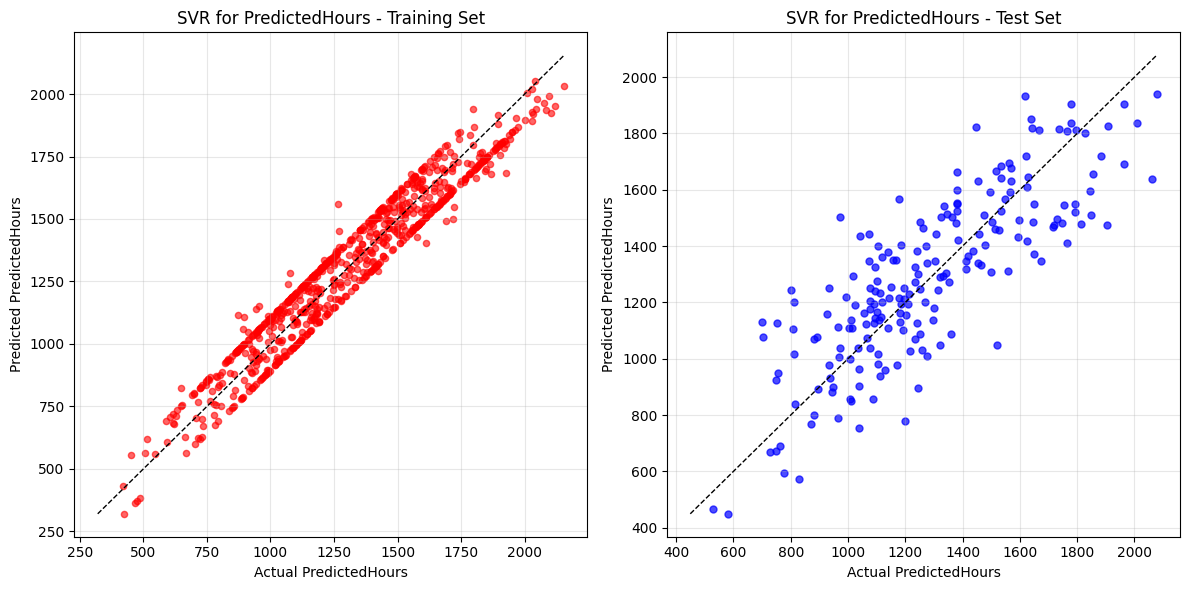

In [7]:
# SVRを使って回帰モデルを作る。
# model_name は、評価結果やグラフタイトルに表示する名前。
model_name = 'SVR for PredictedHours'

# SVR の主なハイパーパラメータを複数試す。
# C は、誤差をどれくらい厳しく抑えるかを表す値。大きいほど学習データに合わせやすくなる。
# gamma は、RBFカーネルの影響範囲を決める値。大きいほど局所的な関係を学習しやすくなる。
# epsilon は、どの程度の予測誤差を許容するかを表す値。今回は目的変数を標準化しているため、標準化後のスケールで指定する。
param_grid = {
    'C': [1, 10, 100, 300],
    'gamma': ['scale', 0.01, 0.03, 0.1],
    'epsilon': [0.05, 0.1, 0.2, 0.3],
}

# SVR は非線形な関係を扱いやすい RBF カーネルを使う。
base_model = SVR(kernel='rbf')

# GridSearchCV は、param_grid の組み合わせを交差検証で比較し、最も良い条件を選ぶ。
# scoring='neg_root_mean_squared_error' は、RMSE が小さいモデルを良いモデルとして評価する設定。
# cv=5 は、学習データを5分割して交差検証するという意味。
model = GridSearchCV(
    base_model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
)

# 標準化したトレーニングデータでモデルを学習する。
# 説明変数 auto_X_train と目的変数 auto_y_train は、どちらも標準化済み。
model.fit(auto_X_train, auto_y_train)

# 選ばれたハイパーパラメータを表示する。
# この条件が、今回の交差検証で最もRMSEが小さかった組み合わせになる。
print(f'最適なパラメータ: {model.best_params_}')
# 交差検証のRMSEは標準化後の目的変数スケールで計算されている。
# y_train_std を掛けることで、PredictedHours の元の単位に戻して表示する。
print(f'交差検証RMSE: {-model.best_score_ * y_train_std:.4f}')

# トレーニングデータに対する予測値を計算し、元のスケールに戻す。
# model.predict は、標準化された目的変数のスケールで予測値を返す。
autoscaled_pred_y_train = model.predict(auto_X_train)
# 標準化を戻す式: 元の値 = 標準化後の値 × 標準偏差 + 平均。
# y_train の平均と標準偏差を使って、予測値を元の目的変数の単位に戻す。
pred_y_train = autoscaled_pred_y_train * y_train_std + y_train_mean
# 予測値を DataFrame に変換する。
# index を auto_X_train と合わせることで、元の行番号との対応を保つ。
pred_y_train = pd.DataFrame(pred_y_train, index=auto_X_train.index, columns=['pred_y'])

# テストデータに対する予測値を計算し、元のスケールに戻す。
# テストデータも、学習データと同じ基準で標準化済みの auto_X_test を使って予測する。
autoscaled_pred_y_test = model.predict(auto_X_test)
# テストデータの予測値も、学習データ y_train の平均と標準偏差を使って元のスケールに戻す。
# 学習時に使ったスケールを基準に戻すため、y_test の平均や標準偏差は使わない。
pred_y_test = autoscaled_pred_y_test * y_train_std + y_train_mean
# テストデータの予測値を DataFrame に変換する。
# index を X_test と合わせることで、実測値 y_test と対応させやすくする。
pred_y_test = pd.DataFrame(pred_y_test, index=X_test.index, columns=['pred_y'])

# 評価指標とグラフを表示する。
# pred_plot 関数では、学習データとテストデータの RMSE, MAE, R2 と散布図をまとめて表示する。
pred_plot(y_train, pred_y_train, y_test, pred_y_test, model_name, target)

# 最良モデルで使われたサポートベクトル数を表示する。
# サポートベクトルは、SVR の予測境界を決めるために使われる重要な学習データ点。
best_svr = model.best_estimator_
print(f'サポートベクトル数: {len(best_svr.support_)} / {X_train.shape[0]}')


In [8]:
# 予測値の一部を表で確認する。
# 評価指標だけでなく、実際の予測値がどの程度ずれているかを表で見る。
# y_test はテストデータの実測値、pred_y_test はテストデータに対する予測値。
# 同じindexを持つ値を並べることで、各サンプルごとの実測値と予測値を比較できる。
prediction_sample = pd.DataFrame(
    {
        # 実測値の列名には、目的変数名 target を含める。
        f'actual_{target}': y_test,
        # 予測値の列名にも target を含め、何を予測した値か分かるようにする。
        f'predicted_{target}': pred_y_test['pred_y'],
        # 絶対誤差を追加すると、各サンプルでどのくらい外れたかを確認しやすい。
        'absolute_error': np.abs(y_test - pred_y_test['pred_y']),
    }
)

# 先頭10行だけ表示する。
# 全件表示すると長くなるため、まずは一部を見て予測結果の雰囲気を確認する。
prediction_sample.head(10)


,actual_PredictedHours,predicted_PredictedHours,absolute_error
521,1567.417,1678.531262,111.114262
737,1826.765,1802.585699,24.179301
740,973.564,1038.103818,64.539818
660,1380.756,1548.016997,167.260997
411,1342.511,1303.044892,39.466108
678,1038.054,962.018990,76.035010
626,1385.680,1420.446509,34.766509
513,870.533,767.699927,102.833073
859,1127.645,959.402728,168.242272
136,1564.055,1593.649186,29.594186
